In [12]:
#임포트
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import cm

In [ ]:
# # 폰트 설정 (서버에 'Malgun Gothic'이 없을 수 있으니, 에러 시 생략 가능)
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False

In [13]:
import platform

# 운영체제에 따라 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux (예: Google Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# Shapefile 경로 (리눅스 경로로 수정)
shp_path1 = 'k-wave/swdata/47_1교차영역.shp'
shp_path2 = 'k-wave/swdata/47_2교차영역.shp'
shp_path3 = 'k-wave/swdata/47_3교차영역.shp'

In [5]:
# 1. Shapefile 불러오기 및 병합
gdf1 = gpd.read_file(shp_path1)
gdf2 = gpd.read_file(shp_path2)
gdf3 = gpd.read_file(shp_path3)

In [6]:
# GeoDataFrame 병합
gdf = gpd.GeoDataFrame(pd.concat([gdf1, gdf2, gdf3], ignore_index=True), crs=gdf1.crs)

In [7]:
# 데이터 확인
print(gdf.head())
print(gdf.crs)


   HSTR_MNNMB ETC_PCMTT FRRD_NM FRRD_FCLT  FRRD_FCLTD FRRD_ESTBL  FRRD_FCLTW  \
0         0.0      None  82번 개일      None         3.9       2014         3.0   
1         0.0      None  82번 개일      None         3.9       2014         3.0   
2         0.0      None  82번 개일      None         3.9       2014         3.0   
3         0.0      None  82번 개일      None         3.9       2014         3.0   
4         0.0      None  82번 개일      None         3.9       2014         3.0   

  FRRD_DV_I FRRD_DV_B FRRD_INSTT  ... PRDN_FOM_C SLANT_TYP  SLDPT_TPCD  \
0         1         2         43  ...         01         1          10   
1         1         2         43  ...         06         3        None   
2         1         2         43  ...       None      None        None   
3         1         2         43  ...         03         2          20   
4         1         2         43  ...         03         2          20   

   SCSTX_CD  SLTP_CD  LDMARK_STN MAP_LABEL_   Shape_Le_1     Shape_Area  \

In [16]:
gdf.columns
gdf['SLTP_CD']

0        13
1        29
2        82
3        14
4        14
         ..
36462    02
36463    01
36464    02
36465    01
36466    02
Name: SLTP_CD, Length: 36467, dtype: object

In [8]:
# 2. 좌표계 통일 (WGS84로)
gdf = gdf.to_crs(epsg=4326)
# 3. 임상코드 정수형으로 변환
gdf['SLTP_CD'] = gdf['SLTP_CD'].astype(int)

# 4. 울릉도 필터링 (경도 130 이상 제거)
gdf['centroid'] = gdf.geometry.centroid
gdf = gdf[gdf.centroid.x < 130]

/tmp/ipykernel_3869783/1139814329.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.geometry.centroid
/tmp/ipykernel_3869783/1139814329.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf = gdf[gdf.centroid.x < 130]


/tmp/ipykernel_3869783/3213007690.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  unique_colors = cm.get_cmap('tab10').colors[:9]


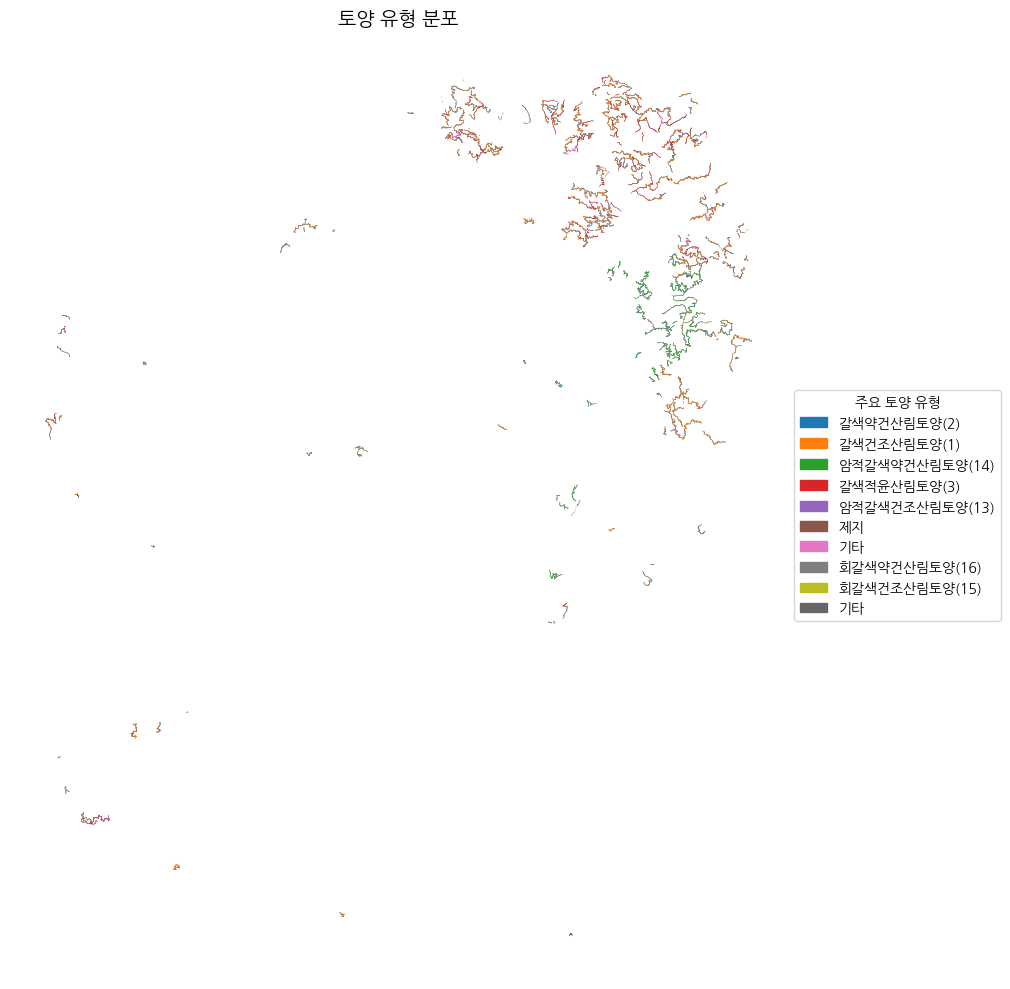

In [17]:
# 1. 코드 → 한글 이름 딕셔너리
code_color_label = {
    "01": "갈색건조산림토양(1)", "02": "갈색약건산림토양(2)", "03": "갈색적윤산림토양(3)",
    "04": "갈색약습산림토양(4)", "05": "적색계갈색건조산림토양(5)", "06": "적색계갈색약건산림토양(6)",
    "07": "적색건조산림토양(7)", "08": "적색약건산림토양(8)", "09": "황색건조산림토양(9)",
    "10": "암적색건조산림토양(10)", "11": "암적색약건산림토양(11)", "12": "암적색적윤산림토양(12)",
    "13": "암적갈색건조산림토양(13)", "14": "암적갈색약건산림토양(14)", "15": "회갈색건조산림토양(15)",
    "16": "회갈색약건산림토양(16)", "17": "화산회건조산림토양(17)", "18": "화산회약건산림토양(18)",
    "19": "화산회적윤산림토양(19)", "20": "화산회습윤산림토양(20)", "21": "화산회자갈많은산림토양(21)",
    "22": "화산회성적색건조산림토양(22)", "23": "화산회성적색약건산림토양(23)", "24": "약침식토양(24)",
    "25": "강침식토양(25)", "26": "사방지토양(26)", "27": "미숙토양(27)", "28": "암쇄토양(28)",
    "29": "전석지", "82": "제지", "91": "주거지", "92": "초지", "93": "경작지",
    "94": "수채", "95": "과수원", "97": "군사지역", "99": "기타"
}

# 2. SLTP_CD 정리 (코드 1 → "01")
gdf['SLTP_CD'] = gdf['SLTP_CD'].astype(str).str.zfill(2)

# 3. 가장 많이 등장한 9개 코드 선택
top9_codes = gdf['SLTP_CD'].value_counts().nlargest(9).index.tolist()

# 4. 고유 색상 설정 (tab10 팔레트)
unique_colors = cm.get_cmap('tab10').colors[:9]
code_to_color = dict(zip(top9_codes, unique_colors))
default_color = '#666666'

# 5. 시각화 시작
fig, ax = plt.subplots(figsize=(10, 10))

# 6. 코드별로 시각화
for code in gdf['SLTP_CD'].unique():
    subset = gdf[gdf['SLTP_CD'] == code]
    color = code_to_color.get(code, default_color)
    subset.plot(
        ax=ax,
        color=color,
        edgecolor=color,
        linewidth=0.2,
        alpha=1.0
    )

# 7. 범례 구성 (한글 라벨 사용)
legend_handles = [
    Patch(
        facecolor=code_to_color[code],
        edgecolor=code_to_color[code],
        label=code_color_label.get(code, f"코드 {code}")
    )
    for code in top9_codes
]
legend_handles.append(Patch(facecolor=default_color, edgecolor=default_color, label="기타"))

# 8. 레이아웃 정리
plt.legend(handles=legend_handles, title="주요 토양 유형", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("토양 유형 분포", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()


In [18]:
#지도 overlap

# import folium


# # 1. SLTP 코드 매핑 딕셔너리
# code_color_label = {
#     "01": "갈색건조산림토양(1)", "02": "갈색약건산림토양(2)", "03": "갈색적윤산림토양(3)",
#     "04": "갈색약습산림토양(4)", "05": "적색계갈색건조산림토양(5)", "06": "적색계갈색약건산림토양(6)",
#     "07": "적색건조산림토양(7)", "08": "적색약건산림토양(8)", "09": "황색건조산림토양(9)",
#     "10": "암적색건조산림토양(10)", "11": "암적색약건산림토양(11)", "12": "암적색적윤산림토양(12)",
#     "13": "암적갈색건조산림토양(13)", "14": "암적갈색약건산림토양(14)", "15": "회갈색건조산림토양(15)",
#     "16": "회갈색약건산림토양(16)", "17": "화산회건조산림토양(17)", "18": "화산회약건산림토양(18)",
#     "19": "화산회적윤산림토양(19)", "20": "화산회습윤산림토양(20)", "21": "화산회자갈많은산림토양(21)",
#     "22": "화산회성적색건조산림토양(22)", "23": "화산회성적색약건산림토양(23)", "24": "약침식토양(24)",
#     "25": "강침식토양(25)", "26": "사방지토양(26)", "27": "미숙토양(27)", "28": "암쇄토양(28)",
#     "29": "전석지", "82": "제지", "91": "주거지", "92": "초지", "93": "경작지",
#     "94": "수채", "95": "과수원", "97": "군사지역", "99": "기타"
# }

# # 2. SLTP 코드 정리
# gdf['SLTP_CD'] = gdf['SLTP_CD'].astype(str).str.zfill(2)

# # 3. 가장 많이 등장한 9개 코드 + 색상
# top9_codes = gdf['SLTP_CD'].value_counts().nlargest(9).index.tolist()
# from matplotlib import cm
# unique_colors = cm.get_cmap('tab10').colors[:9]
# import matplotlib.colors as mcolors
# color_hex = [mcolors.to_hex(c) for c in unique_colors]
# code_to_color = dict(zip(top9_codes, color_hex))
# default_color = '#666666'

# # 4. 색상 컬럼 추가
# gdf['fillColor'] = gdf['SLTP_CD'].apply(lambda x: code_to_color.get(x, default_color))

# # 5. 지도 중심 계산
# center = gdf.geometry.unary_union.centroid

# # 6. folium 지도 생성
# m = folium.Map(location=[center.y, center.x], zoom_start=10, tiles='CartoDB positron')

# # 7. 스타일 함수
# def style_function(feature):
#     code = feature['properties']['SLTP_CD']
#     return {
#         'fillColor': code_to_color.get(code, default_color),
#         'color': code_to_color.get(code, default_color),
#         'weight': 0.5,
#         'fillOpacity': 0.7
#     }

# # 8. GeoJson 추가
# folium.GeoJson(
#     gdf,
#     name="산림 토양 유형",
#     style_function=style_function,
#     tooltip=folium.GeoJsonTooltip(fields=["SLTP_CD"])
# ).add_to(m)

# # 9. 범례 생성
# legend_html = '''
# <div style="position: fixed; bottom: 50px; left: 50px; width: 220px; height: auto;
#      border:2px solid grey; z-index:9999; font-size:13px; background-color:white; padding:10px;">
# <b>주요 토양 유형</b><br>
# '''
# for code in top9_codes:
#     label = code_color_label.get(code, f"코드 {code}")
#     color = code_to_color.get(code)
#     legend_html += f'<div style="color:{color}">■ {label}</div>'
# legend_html += '<div style="color:#666666">■ 기타</div>'
# legend_html += '</div>'

# m.get_root().html.add_child(folium.Element(legend_html))

# # 10. 지도 출력
# m


In [ ]:
print(gdf.crs)  # EPSG:4326 인가?
print(len(gdf))  # 0이면 안 됨
print(gdf.geometry.is_empty.sum())  # 비어있는 도형 많은가?
gdf.explore()  # geopandas 자체 지도 기능으로 확인


EPSG:4326
36467
0
